<a href="https://colab.research.google.com/github/ncrowder/maven/blob/main/maven_drill_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# https://mavenanalytics.io/data-drills/splitting-the-field

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv(r'https://maven-datasets.s3.us-east-1.amazonaws.com/Data+Drills/baseball_positions.csv')

In [ ]:
df.head() # Some players play multiple positions

,Name,Team,Position
0,Aaron Judge,NYY,OF/DH
1,Cal Raleigh,SEA,C/DH
2,Shohei Ohtani,LAD,DH
3,Juan Soto,NYM,OF
4,Tarik Skubal,DET,SP


# Original Q: How many players make up the third most popular position?

In [ ]:
df.Position = df.Position.str.split('/') # Setting up for the use of the explode method

In [ ]:
df.head()

,Name,Team,Position
0,Aaron Judge,NYY,"[OF, DH]"
1,Cal Raleigh,SEA,"[C, DH]"
2,Shohei Ohtani,LAD,[DH]
3,Juan Soto,NYM,[OF]
4,Tarik Skubal,DET,[SP]


In [ ]:
df = df.explode('Position').reset_index(drop=True)

In [ ]:
df.head() # After exploding players (e.g. Aaron Judge can be more easily counted in both positions they played)

,Name,Team,Position
0,Aaron Judge,NYY,OF
1,Aaron Judge,NYY,DH
2,Cal Raleigh,SEA,C
3,Cal Raleigh,SEA,DH
4,Shohei Ohtani,LAD,DH


In [ ]:
df.groupby('Position')['Name'].count().sort_values(ascending=False)

,Name
Position,
OF,294
SP,227
RP,222
DH,134
3B,127
2B,125
1B,114
C,106
SS,85


In [ ]:
# A: The position with the third most different players (RP) had 222 unique players.

# Let's look by both team and player now

In [ ]:
df.groupby(['Team','Position'])['Name'].count().sort_values(ascending=False) # Players play the same position for multiple teams!

,,Name
Team,Position,
DET,OF,13
KCR,OF,12
CHW,OF,11
HOU,OF,11
CLE,OF,11
...,...,...
WSN/BOS,1B,1
WSN/CHC,SP,1
WSN/DET,RP,1


In [ ]:
# Now repeat the split and explode pattern for the Team column as well
df['Team'] = df.Team.str.split('/')
df = df.explode('Team').reset_index(drop=True)

In [ ]:
dfteampos = df.groupby(['Team','Position'])['Name'].count().sort_values(ascending=False) # Two teams (BAL and CHW) had 16 players play at the OF position
dfteampos

Team  Position
BAL   OF          16
CHW   OF          16
KCR   OF          15
CIN   OF          14
LAD   SP          14
                  ..
MIL   2B           1
PHI   SS           1
      DH           1
ATL   1B           1
SEA   SS           1
Name: Name, Length: 270, dtype: int64

In [ ]:
dfteampos[dfteampos==1]
# Only 8 teams had a single player in any single position the entire season, and PHI was the only team where this was true for 2 positions
# Additionally, Shortstop seems to be by far and away the position that is most likely to be covered by a single player all season
# This ignores the fact that OF is really 3 distinct positions

Team  Position
DET   1B          1
KCR   SS          1
CIN   SS          1
NYM   SS          1
MIL   2B          1
PHI   SS          1
      DH          1
ATL   1B          1
SEA   SS          1
Name: Name, dtype: int64

In [ ]:
# Unstacking allows us to see all the data at once in a 2d matrix-style layout
dfmatrix = df.groupby(['Team','Position'])['Name'].count().sort_values(ascending=False).unstack()
dfmatrix

Position,1B,2B,3B,C,DH,OF,RP,SP,SS
Team,,,,,,,,,
ARI,6,5,4,4,7,8,6,6,3
ATH,4,5,8,4,3,11,7,10,3
ATL,1,5,5,4,5,12,9,12,6
BAL,5,5,7,7,7,16,8,8,4
BOS,7,5,3,4,4,8,10,11,2
CHC,4,4,6,4,6,9,9,9,4
CHW,8,4,7,5,6,16,8,11,5
CIN,4,2,6,4,5,14,8,7,1
CLE,2,5,3,3,5,11,8,8,2


In [ ]:
import matplotlib.pyplot as plt

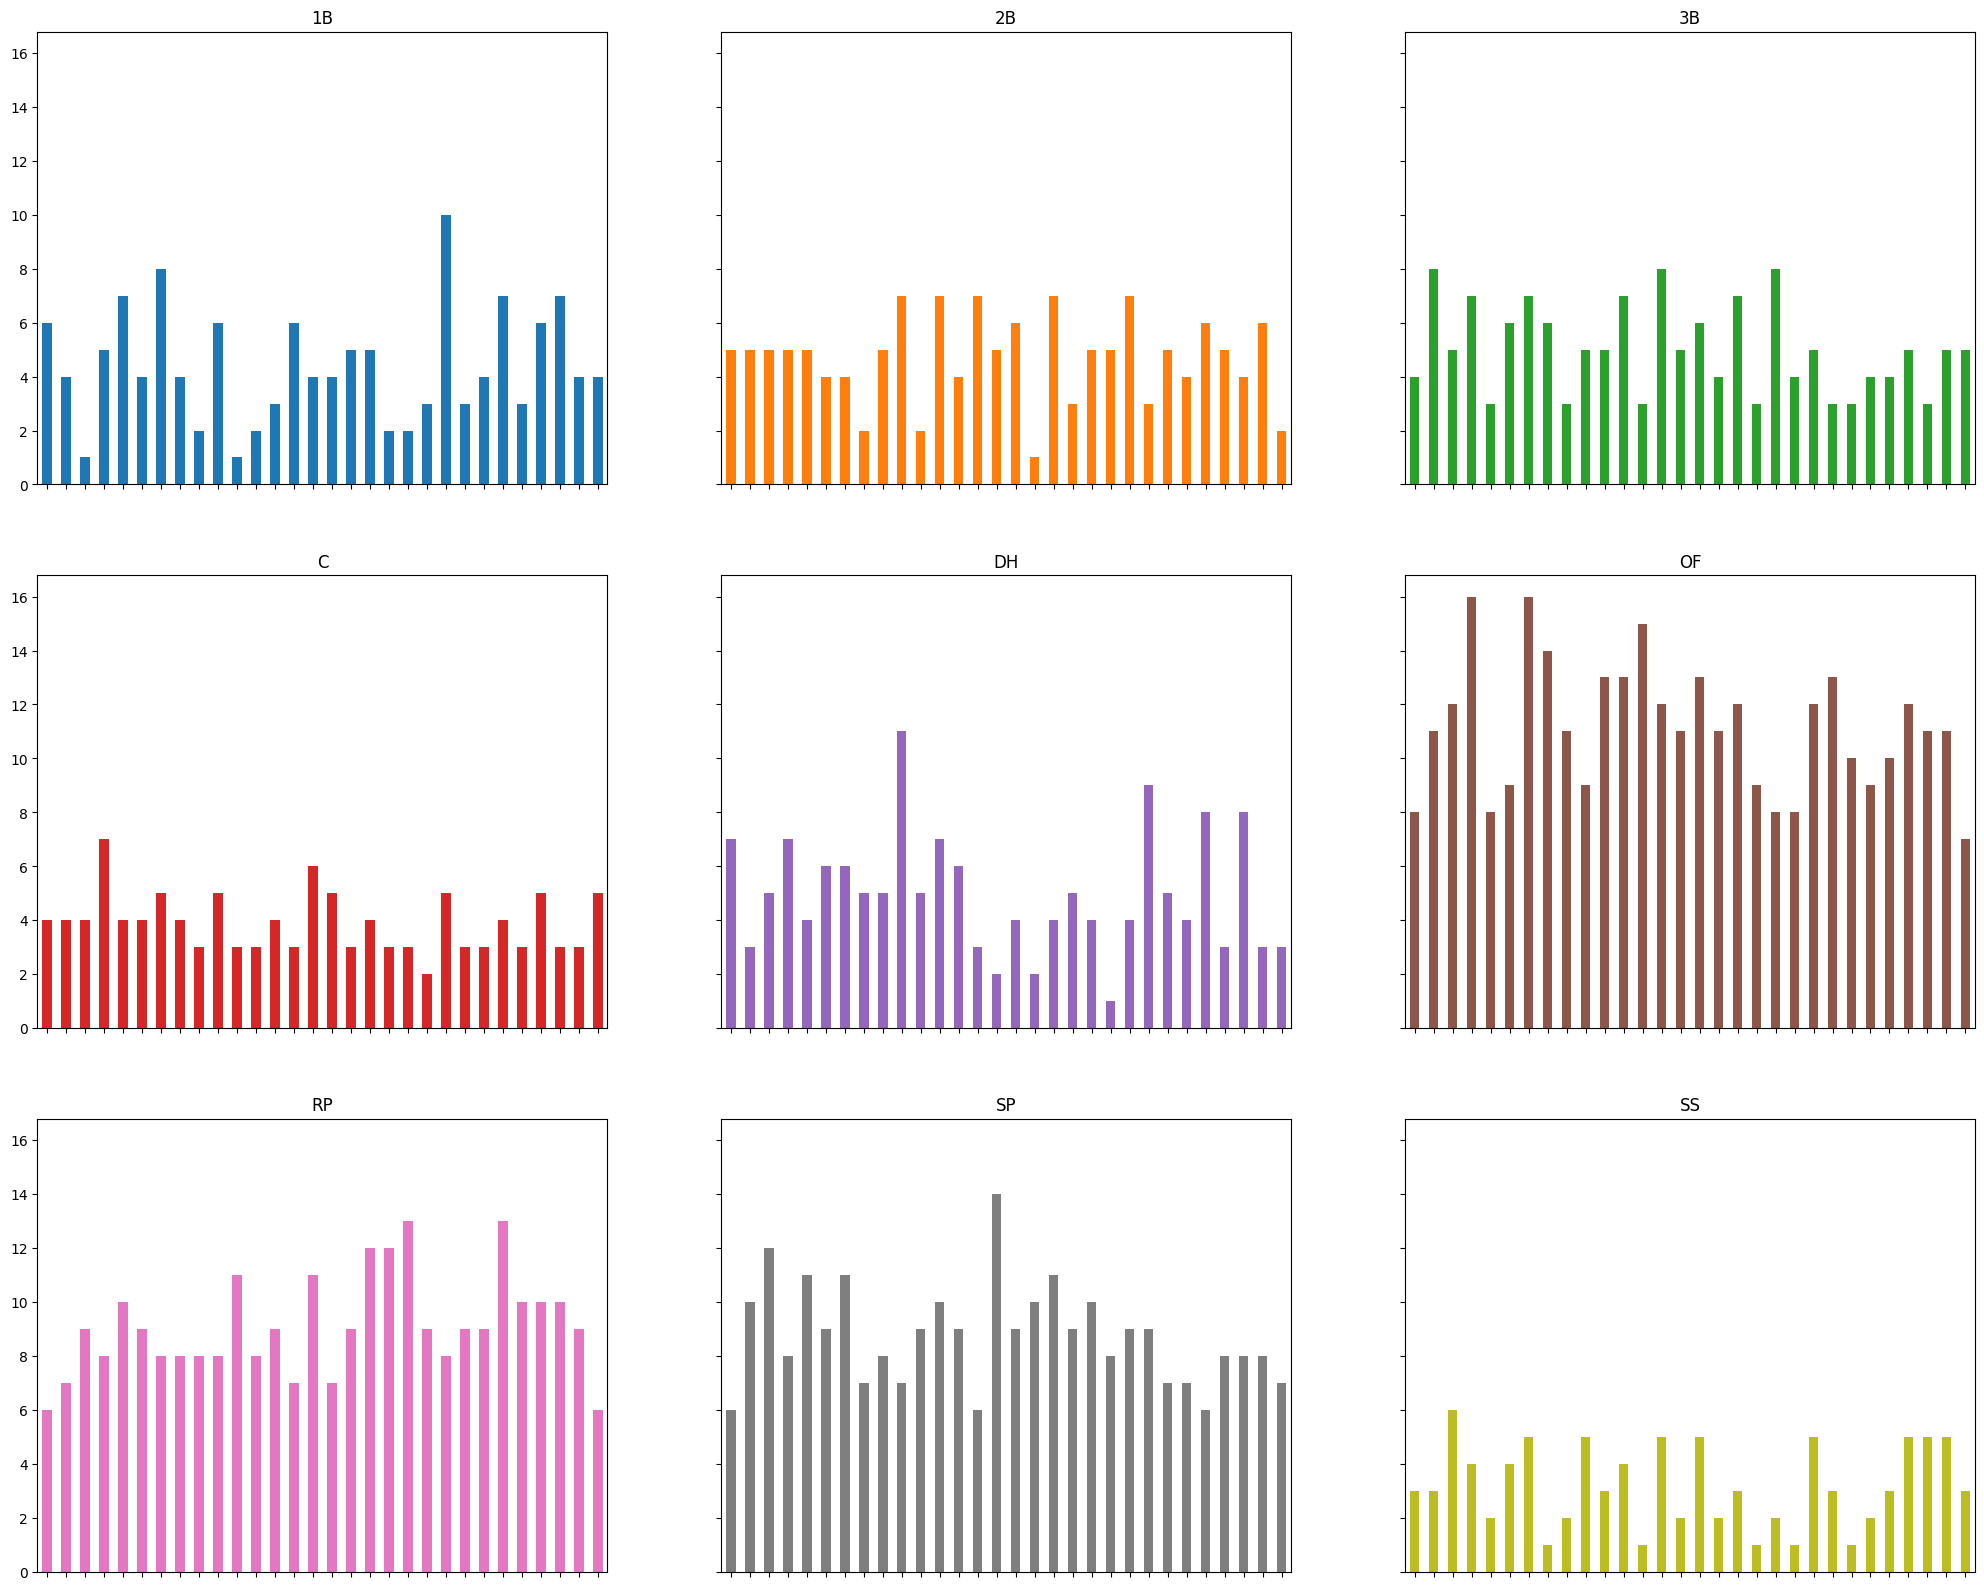

In [ ]:
axes = dfmatrix.plot.bar(
    subplots=True,
    layout=(3, 3),
    figsize=(25, 20),
    legend=False,
    sharey=True,
    sharex=False
)
for ax in axes.ravel():
    ax.set_xlabel('')
    ax.tick_params(labelbottom=False)